**โจทย์:** ประเมินความเข้มกลิ่นจากค่าของเซนเซอร์ เพื่อตรวจจับเหตุการณ์ผิดปกติ (Anomaly Detection)  
**กระบวนการ:** Data Science Process 6 ขั้นตอน

---
## Step 1 — Setting the Research Goal

### บริบทของปัญหา
หน้างาน (โรงงาน/โรงบำบัดน้ำเสีย) ติดตั้งสถานีตรวจวัดกลิ่นต่อเนื่อง ชุมชนรอบข้างร้องเรียนเรื่องกลิ่นรบกวนบ่อยขึ้น ผู้จัดการต้องการเครื่องมือที่ช่วยให้:
- เข้าใจสถานการณ์กลิ่นจากข้อมูล sensor
- ตอบข้อร้องเรียนได้อย่างมีหลักฐาน
- ตัดสินใจได้เร็วขึ้นว่าควรแก้ไขที่จุดใด เมื่อใด

### Research Goal
> **"ประเมินความเข้มกลิ่น (D/T) จากค่าของ sensor ทั้ง 8 ตัว และตรวจจับช่วงเวลาที่กลิ่นผิดปกติ เพื่อสนับสนุนการตัดสินใจของหน้างาน"**

---
## Step 2 — Retrieving Data

ข้อมูลมาจากสถานีตรวจวัดกลิ่น ENose บันทึกค่าทุก **1 นาที** ต่อเนื่องประมาณ **91 วัน**  
ไฟล์: `Export.csv` — เป็นข้อมูลจริงที่ยังไม่ผ่านการทำความสะอาด

### หมายเหตุการโหลดไฟล์
ไฟล์นี้มีบรรทัดแรกเป็น `sep=,` ซึ่งเป็น Excel dialect — ต้องใช้ `skiprows=1` เพื่อข้ามบรรทัดนั้น

In [2]:
import pandas as pd
import numpy as np

# โหลดข้อมูล — skiprows=1 เพื่อข้ามบรรทัด sep=,
df = pd.read_csv("Export.csv", skiprows=1)

# แปลง Time เป็น datetime
df["Time"] = pd.to_datetime(df["Time"])

print(f"โหลดสำเร็จ: {df.shape[0]:,} แถว, {df.shape[1]} คอลัมน์")
print(f"ช่วงเวลา: {df['Time'].min()} ถึง {df['Time'].max()}")

โหลดสำเร็จ: 130,343 แถว, 17 คอลัมน์
ช่วงเวลา: 2026-02-12 00:00:00 ถึง 2026-05-14 12:31:00


### 2.1 ดูโครงสร้างข้อมูล

In [3]:
# ดูตัวอย่างข้อมูล
df.head(5)

,Time,D/T,Wind Direction,Wind Speed,Temperature,Relative Humidity,PM 2.5,Atmospheric Pressure,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Smell Prediction
0,2026-02-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
1,2026-02-12 00:01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
2,2026-02-12 00:02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
3,2026-02-12 00:03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
4,2026-02-12 00:04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient


In [4]:
# ดู data type ของแต่ละคอลัมน์
df.dtypes

Time                    datetime64[ns]
D/T                            float64
Wind Direction                 float64
Wind Speed                     float64
Temperature                    float64
Relative Humidity              float64
PM 2.5                         float64
Atmospheric Pressure           float64
Sensor 1                       float64
Sensor 2                       float64
Sensor 3                       float64
Sensor 4                       float64
Sensor 5                       float64
Sensor 6                       float64
Sensor 7                       float64
Sensor 8                       float64
Smell Prediction                object
dtype: object

### 2.2 ตรวจสอบ Missing Values

In [5]:
# นับ missing values แต่ละคอลัมน์
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})
missing_summary[missing_summary["Missing Count"] > 0]

,Missing Count,Missing %
D/T,421,0.32
Wind Direction,422,0.32
Wind Speed,422,0.32
Temperature,422,0.32
Relative Humidity,422,0.32
PM 2.5,422,0.32
Atmospheric Pressure,422,0.32
Sensor 1,421,0.32
Sensor 2,421,0.32
Sensor 3,421,0.32


### 2.3 ดู Smell Prediction — target variable

In [6]:
# นับค่าใน Smell Prediction (รวม NaN)
print("=== Smell Prediction value_counts ===")
print(df["Smell Prediction"].value_counts(dropna=False))

print("\n=== แถวที่ Sensor ว่างทุกตัว ===")
sensor_cols = [f"Sensor {i}" for i in range(1, 9)]
all_sensor_null = df[sensor_cols].isnull().all(axis=1)
print(f"Sensor ว่างทุกตัว : {all_sensor_null.sum():,} แถว")
print(f"Sensor มีข้อมูล   : {(~all_sensor_null).sum():,} แถว")

=== Smell Prediction value_counts ===
Smell Prediction
Ambient        85504
NaN            44838
hackathon#2        1
Name: count, dtype: int64

=== แถวที่ Sensor ว่างทุกตัว ===
Sensor ว่างทุกตัว : 421 แถว
Sensor มีข้อมูล   : 129,922 แถว


### 2.4 สรุปสิ่งที่พบ

| ประเด็น | รายละเอียด | แนวทาง Step 3 |
|---|---|---|
| Sensor NaN 421 แถว | ~0.3% — sensor ว่างทุกตัว | ตัดทิ้ง |
| `hackathon#2` 1 แถว | ไม่ใช่ข้อมูลจริง | ตัดทิ้ง |
| Smell Prediction NaN 44,838 แถว | 34% — ยังไม่ทราบสาเหตุ | ต้องวิเคราะห์เพิ่ม |
| มีแค่ "Ambient" | ทั้งที่สเปกรองรับ 5 โปรไฟล์ | ต้องใช้ D/T แทน label |

---
## Step 3 — Data Preparation

ขั้นตอนนี้เป็นการทำความสะอาดและเตรียมข้อมูลจาก `Export.csv` ที่โหลดมาใน Step 2  
เพื่อให้ข้อมูลพร้อมสำหรับการทำ Data Exploration และ Data Modeling

จาก Step 2 พบปัญหาหลักคือ:
- มีแถวที่ Sensor 1–8 ว่างทุกตัว
- มี marker `hackathon#2` ซึ่งไม่ใช่ข้อมูลจริง
- `Smell Prediction` มีค่า NaN จำนวนมาก และมีเพียงค่า `Ambient`
- จึงเลือกใช้ `D/T` เป็น target หลักแทน `Smell Prediction`

### 3.1 กำหนดคอลัมน์ที่ใช้

In [7]:
# กำหนดคอลัมน์ sensor
sensor_cols = [f"Sensor {i}" for i in range(1, 9)]

# คอลัมน์ตัวเลขที่ต้องใช้ในการวิเคราะห์
numeric_cols = [
    "D/T",
    "Wind Direction",
    "Wind Speed",
    "Temperature",
    "Relative Humidity",
    "PM 2.5",
    "Atmospheric Pressure"
] + sensor_cols

print("Sensor columns:", sensor_cols)
print("Numeric columns:", numeric_cols)

Sensor columns: ['Sensor 1', 'Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 5', 'Sensor 6', 'Sensor 7', 'Sensor 8']
Numeric columns: ['D/T', 'Wind Direction', 'Wind Speed', 'Temperature', 'Relative Humidity', 'PM 2.5', 'Atmospheric Pressure', 'Sensor 1', 'Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 5', 'Sensor 6', 'Sensor 7', 'Sensor 8']


### 3.2 แปลงชนิดข้อมูลให้ถูกต้อง

In [8]:
import pandas as pd
import numpy as np
from IPython.display import display

# ถ้ายังไม่มี df ให้โหลดไฟล์ใหม่
if "df" not in globals():
    df = pd.read_csv("Export.csv", skiprows=1)

# ตัดช่องว่างชื่อคอลัมน์
df.columns = df.columns.str.strip()

sensor_cols = [f"Sensor {i}" for i in range(1, 9)]

numeric_cols = [
    "D/T",
    "Wind Direction",
    "Wind Speed",
    "Temperature",
    "Relative Humidity",
    "PM 2.5",
    "Atmospheric Pressure"
] + sensor_cols

# แปลง Time
df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

# แปลงตัวเลข
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("✅ แปลงชนิดข้อมูลเรียบร้อย")
print("ขนาดข้อมูล:", df.shape)

display(df[numeric_cols + ["Time"]].dtypes.to_frame("dtype"))
display(df.head())

✅ แปลงชนิดข้อมูลเรียบร้อย
ขนาดข้อมูล: (130343, 17)


,dtype
D/T,float64
Wind Direction,float64
Wind Speed,float64
Temperature,float64
Relative Humidity,float64
PM 2.5,float64
Atmospheric Pressure,float64
Sensor 1,float64
Sensor 2,float64
Sensor 3,float64


,Time,D/T,Wind Direction,Wind Speed,Temperature,Relative Humidity,PM 2.5,Atmospheric Pressure,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Smell Prediction
0,2026-02-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
1,2026-02-12 00:01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
2,2026-02-12 00:02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
3,2026-02-12 00:03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
4,2026-02-12 00:04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient


### 3.3 ลบข้อมูลที่ไม่ใช่ข้อมูลจริง

In [9]:
before_rows = len(df)

df_clean = df[
    ~df["Smell Prediction"].astype(str).str.contains("hackathon", case=False, na=False)
].copy()

after_rows = len(df_clean)

print("✅ ลบข้อมูล marker ที่ไม่ใช่ข้อมูลจริง")
print(f"ก่อนลบ : {before_rows:,} แถว")
print(f"หลังลบ : {after_rows:,} แถว")
print(f"ลบออก : {before_rows - after_rows:,} แถว")

display(df_clean.head())

✅ ลบข้อมูล marker ที่ไม่ใช่ข้อมูลจริง
ก่อนลบ : 130,343 แถว
หลังลบ : 130,342 แถว
ลบออก : 1 แถว


,Time,D/T,Wind Direction,Wind Speed,Temperature,Relative Humidity,PM 2.5,Atmospheric Pressure,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Smell Prediction
0,2026-02-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
1,2026-02-12 00:01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
2,2026-02-12 00:02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
3,2026-02-12 00:03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
4,2026-02-12 00:04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient


### 3.4 ลบแถวที่ Sensor 1–8 ว่างทั้งหมด

In [10]:
before_rows = len(df_clean)

all_sensor_null = df_clean[sensor_cols].isna().all(axis=1)
removed_rows = df_clean[all_sensor_null]

df_clean = df_clean[~all_sensor_null].copy()

after_rows = len(df_clean)

print("✅ ลบแถวที่ Sensor 1–8 ว่างทั้งหมด")
print(f"ก่อนลบ : {before_rows:,} แถว")
print(f"หลังลบ : {after_rows:,} แถว")
print(f"ลบออก : {before_rows - after_rows:,} แถว")

print("\nตัวอย่างแถวที่ถูกลบ:")
display(removed_rows.head())

✅ ลบแถวที่ Sensor 1–8 ว่างทั้งหมด
ก่อนลบ : 130,342 แถว
หลังลบ : 129,921 แถว
ลบออก : 421 แถว

ตัวอย่างแถวที่ถูกลบ:


,Time,D/T,Wind Direction,Wind Speed,Temperature,Relative Humidity,PM 2.5,Atmospheric Pressure,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Smell Prediction
0,2026-02-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
1,2026-02-12 00:01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
2,2026-02-12 00:02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
3,2026-02-12 00:03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient
4,2026-02-12 00:04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ambient


### 3.5 ตรวจสอบค่าที่อยู่นอกช่วงตามสเปก

In [11]:
valid_ranges = {
    "D/T": (0, 60),
    "Wind Direction": (0, 360),
    "Wind Speed": (0, 40),
    "Temperature": (-40, 85),
    "Relative Humidity": (0, 100),
    "PM 2.5": (0, 1000),
    "Atmospheric Pressure": (500, 1100)
}

out_summary = []

for col, (low, high) in valid_ranges.items():
    out_of_range = df_clean[col].notna() & ~df_clean[col].between(low, high)
    out_summary.append({
        "column": col,
        "valid_range": f"{low} ถึง {high}",
        "out_of_range_rows": int(out_of_range.sum())
    })

out_summary_df = pd.DataFrame(out_summary)

print("✅ ตรวจสอบค่าที่อยู่นอกช่วงตามสเปก")
display(out_summary_df)

✅ ตรวจสอบค่าที่อยู่นอกช่วงตามสเปก


,column,valid_range,out_of_range_rows
0,D/T,0 ถึง 60,0
1,Wind Direction,0 ถึง 360,0
2,Wind Speed,0 ถึง 40,0
3,Temperature,-40 ถึง 85,0
4,Relative Humidity,0 ถึง 100,0
5,PM 2.5,0 ถึง 1000,0
6,Atmospheric Pressure,500 ถึง 1100,1447


### 3.6 ลบแถวที่มีค่าหลุดช่วงตามสเปก

In [12]:
before_rows = len(df_clean)

valid_mask = pd.Series(True, index=df_clean.index)

for col, (low, high) in valid_ranges.items():
    valid_mask = valid_mask & (
        df_clean[col].isna() | df_clean[col].between(low, high)
    )

removed_out_range = df_clean[~valid_mask]
df_clean = df_clean[valid_mask].copy()

after_rows = len(df_clean)

print("✅ ลบแถวที่มีค่าหลุดช่วงตามสเปก")
print(f"ก่อนลบ : {before_rows:,} แถว")
print(f"หลังลบ : {after_rows:,} แถว")
print(f"ลบออก : {before_rows - after_rows:,} แถว")

print("\nตัวอย่างแถวที่ถูกลบ:")
display(removed_out_range.head())

✅ ลบแถวที่มีค่าหลุดช่วงตามสเปก
ก่อนลบ : 129,921 แถว
หลังลบ : 128,474 แถว
ลบออก : 1,447 แถว

ตัวอย่างแถวที่ถูกลบ:


,Time,D/T,Wind Direction,Wind Speed,Temperature,Relative Humidity,PM 2.5,Atmospheric Pressure,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Smell Prediction
420,2026-02-12 07:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ambient
421,2026-02-12 07:01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ambient
422,2026-02-12 07:02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ambient
423,2026-02-12 07:03:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ambient
424,2026-02-12 07:04:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ambient


### 3.7 จัดการ Missing Values สำหรับคอลัมน์ที่ใช้ทำโมเดล

In [13]:
feature_cols = sensor_cols + [
    "Wind Direction",
    "Wind Speed",
    "Temperature",
    "Relative Humidity",
    "PM 2.5",
    "Atmospheric Pressure"
]

target_col = "D/T"

before_rows = len(df_clean)

missing_before = df_clean[feature_cols + [target_col]].isna().sum().to_frame("missing_before")

df_clean = df_clean.dropna(subset=feature_cols + [target_col]).copy()

after_rows = len(df_clean)

missing_after = df_clean[feature_cols + [target_col]].isna().sum().to_frame("missing_after")
missing_summary = missing_before.join(missing_after)

print("✅ จัดการ Missing Values ใน feature และ target")
print(f"ก่อนลบ : {before_rows:,} แถว")
print(f"หลังลบ : {after_rows:,} แถว")
print(f"ลบออก : {before_rows - after_rows:,} แถว")

display(missing_summary)

✅ จัดการ Missing Values ใน feature และ target
ก่อนลบ : 128,474 แถว
หลังลบ : 128,473 แถว
ลบออก : 1 แถว


,missing_before,missing_after
Sensor 1,0,0
Sensor 2,0,0
Sensor 3,0,0
Sensor 4,0,0
Sensor 5,0,0
Sensor 6,0,0
Sensor 7,0,0
Sensor 8,0,0
Wind Direction,1,0
Wind Speed,1,0


### 3.8 สร้าง Feature จากเวลา

In [14]:
df_clean["hour"] = df_clean["Time"].dt.hour
df_clean["day"] = df_clean["Time"].dt.day
df_clean["month"] = df_clean["Time"].dt.month
df_clean["dayofweek"] = df_clean["Time"].dt.dayofweek
df_clean["is_weekend"] = df_clean["dayofweek"].isin([5, 6]).astype(int)

time_cols = ["hour", "day", "month", "dayofweek", "is_weekend"]

print("✅ สร้าง Feature จากเวลาเรียบร้อย")
display(df_clean[["Time"] + time_cols].head())

✅ สร้าง Feature จากเวลาเรียบร้อย


,Time,hour,day,month,dayofweek,is_weekend
808,2026-02-12 13:28:00,13,12,2,3,0
809,2026-02-12 13:29:00,13,12,2,3,0
810,2026-02-12 13:30:00,13,12,2,3,0
811,2026-02-12 13:31:00,13,12,2,3,0
812,2026-02-12 13:32:00,13,12,2,3,0


### 3.9 เตรียมข้อมูลสำหรับขั้นตอน Modeling

In [15]:
final_feature_cols = feature_cols + time_cols

X = df_clean[final_feature_cols]
y = df_clean[target_col]

print("✅ เตรียมข้อมูลสำหรับ Modeling เรียบร้อย")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\nตัวอย่าง X:")
display(X.head())

print("\nตัวอย่าง y:")
display(y.head().to_frame("D/T"))

✅ เตรียมข้อมูลสำหรับ Modeling เรียบร้อย
X shape: (128473, 19)
y shape: (128473,)

ตัวอย่าง X:


,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Wind Direction,Wind Speed,Temperature,Relative Humidity,PM 2.5,Atmospheric Pressure,hour,day,month,dayofweek,is_weekend
808,82.00,82.00,415.00,56.00,22.00,243.00,264.0,250.06,210.9,0.0,24.51,40.33,47.50,1011.1,13,12,2,3,0
809,82.00,82.00,414.74,56.00,22.00,242.98,264.0,250.00,210.9,0.0,24.50,40.31,47.00,1011.0,13,12,2,3,0
810,82.55,82.55,414.00,55.69,22.00,242.92,264.0,250.00,210.9,0.0,24.55,40.20,46.33,1011.0,13,12,2,3,0
811,82.99,82.99,413.97,55.00,21.99,242.66,264.0,250.00,210.9,0.0,24.56,40.06,48.00,1011.0,13,12,2,3,0
812,83.00,83.00,413.90,55.00,21.75,242.92,264.0,250.00,210.9,0.0,24.56,40.04,48.50,1011.0,13,12,2,3,0



ตัวอย่าง y:


,D/T
808,1.39
809,1.35
810,1.35
811,1.35
812,1.34


### 3.10 สรุปผลหลัง Data Preparation

In [16]:
summary_data = {
    "รายการ": [
        "จำนวนข้อมูลหลังทำความสะอาด",
        "จำนวนคอลัมน์หลังทำความสะอาด",
        "เวลาเริ่มต้น",
        "เวลาสิ้นสุด",
        "จำนวน feature ที่ใช้ทำโมเดล",
        "target"
    ],
    "ค่า": [
        f"{df_clean.shape[0]:,} แถว",
        f"{df_clean.shape[1]} คอลัมน์",
        str(df_clean["Time"].min()),
        str(df_clean["Time"].max()),
        f"{len(final_feature_cols)} features",
        target_col
    ]
}

summary_df = pd.DataFrame(summary_data)

print("✅ Data Preparation Summary")
display(summary_df)

print("\nสถิติของ D/T หลังทำความสะอาด:")
display(df_clean["D/T"].describe().to_frame("D/T"))

✅ Data Preparation Summary


,รายการ,ค่า
0,จำนวนข้อมูลหลังทำความสะอาด,"128,473 แถว"
1,จำนวนคอลัมน์หลังทำความสะอาด,22 คอลัมน์
2,เวลาเริ่มต้น,2026-02-12 13:28:00
3,เวลาสิ้นสุด,2026-05-14 12:31:00
4,จำนวน feature ที่ใช้ทำโมเดล,19 features
5,target,D/T



สถิติของ D/T หลังทำความสะอาด:


,D/T
count,128473.000000
mean,1.638379
std,1.661292
min,0.000000
25%,0.300000
50%,0.480000
75%,2.930000
max,8.780000


### สรุป Step 3

ในขั้นตอน Data Preparation เราได้ทำความสะอาดข้อมูลจากไฟล์ `Export.csv` โดยลบข้อมูลที่ไม่ใช่ข้อมูลจริง เช่น `hackathon#2` ลบแถวที่ Sensor 1–8 ว่างทั้งหมด ตรวจสอบค่าที่อยู่นอกช่วงตามสเปก จัดการ missing values และสร้าง feature จากเวลา

หลังจากขั้นตอนนี้ ข้อมูลจะพร้อมสำหรับ Step 4 — Data Exploration และ Step 5 — Data Modeling โดยใช้ค่า `D/T` เป็น target สำหรับการประเมินความเข้มกลิ่น 

---
## Step 4 — Data Exploration

ขั้นตอนนี้เป็นการสำรวจข้อมูลหลังจากทำความสะอาดแล้ว เพื่อดูรูปแบบของข้อมูล ความสัมพันธ์ระหว่างตัวแปร และแนวโน้มของค่า D/T ซึ่งเป็นค่าความเข้มกลิ่น

เป้าหมายของขั้นตอนนี้คือ:
- ดูการกระจายตัวของค่า D/T
- ดูว่าช่วงเวลาใดมีกลิ่นแรง
- ดูความสัมพันธ์ระหว่าง Sensor 1–8 กับค่า D/T
- ดูความสัมพันธ์ระหว่างสภาพอากาศกับความเข้มกลิ่น
- หา insight เบื้องต้นก่อนเข้าสู่ขั้นตอน Data Modeling

### 4.1 ตรวจสอบข้อมูลหลังทำความสะอาด

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# ถ้ายังไม่มี df_clean ให้สร้างจาก Export.csv แบบรวบรัด
if "df_clean" not in globals():
    print("ยังไม่มี df_clean → กำลังโหลดและทำความสะอาดข้อมูลเบื้องต้นจาก Export.csv")

    df = pd.read_csv("Export.csv", skiprows=1)
    df.columns = df.columns.str.strip()

    sensor_cols = [f"Sensor {i}" for i in range(1, 9)]

    numeric_cols = [
        "D/T",
        "Wind Direction",
        "Wind Speed",
        "Temperature",
        "Relative Humidity",
        "PM 2.5",
        "Atmospheric Pressure"
    ] + sensor_cols

    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # ลบ marker hackathon
    df_clean = df[
        ~df["Smell Prediction"].astype(str).str.contains("hackathon", case=False, na=False)
    ].copy()

    # ลบแถวที่ Sensor 1-8 ว่างทั้งหมด
    df_clean = df_clean[~df_clean[sensor_cols].isna().all(axis=1)].copy()

    # ตรวจค่าตามช่วงสเปก
    valid_ranges = {
        "D/T": (0, 60),
        "Wind Direction": (0, 360),
        "Wind Speed": (0, 40),
        "Temperature": (-40, 85),
        "Relative Humidity": (0, 100),
        "PM 2.5": (0, 1000),
        "Atmospheric Pressure": (500, 1100)
    }

    valid_mask = pd.Series(True, index=df_clean.index)

    for col, (low, high) in valid_ranges.items():
        valid_mask = valid_mask & (
            df_clean[col].isna() | df_clean[col].between(low, high)
        )

    df_clean = df_clean[valid_mask].copy()

else:
    print("พบ df_clean แล้ว → ใช้ข้อมูลจาก Step 3 ต่อได้เลย")

# กันกรณีตัวแปรอื่นยังไม่มี
if "sensor_cols" not in globals():
    sensor_cols = [f"Sensor {i}" for i in range(1, 9)]

if "target_col" not in globals():
    target_col = "D/T"

print("✅ ตรวจสอบข้อมูลหลังทำความสะอาด")
print(f"จำนวนแถว: {df_clean.shape[0]:,}")
print(f"จำนวนคอลัมน์: {df_clean.shape[1]}")

display(df_clean.head())
display(df_clean.describe())

พบ df_clean แล้ว → ใช้ข้อมูลจาก Step 3 ต่อได้เลย
✅ ตรวจสอบข้อมูลหลังทำความสะอาด
จำนวนแถว: 128,473
จำนวนคอลัมน์: 22


,Time,D/T,Wind Direction,Wind Speed,Temperature,Relative Humidity,PM 2.5,Atmospheric Pressure,Sensor 1,Sensor 2,...,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Smell Prediction,hour,day,month,dayofweek,is_weekend
808,2026-02-12 13:28:00,1.39,210.9,0.0,24.51,40.33,47.50,1011.1,82.00,82.00,...,22.00,243.00,264.0,250.06,Ambient,13,12,2,3,0
809,2026-02-12 13:29:00,1.35,210.9,0.0,24.50,40.31,47.00,1011.0,82.00,82.00,...,22.00,242.98,264.0,250.00,Ambient,13,12,2,3,0
810,2026-02-12 13:30:00,1.35,210.9,0.0,24.55,40.20,46.33,1011.0,82.55,82.55,...,22.00,242.92,264.0,250.00,Ambient,13,12,2,3,0
811,2026-02-12 13:31:00,1.35,210.9,0.0,24.56,40.06,48.00,1011.0,82.99,82.99,...,21.99,242.66,264.0,250.00,Ambient,13,12,2,3,0
812,2026-02-12 13:32:00,1.34,210.9,0.0,24.56,40.04,48.50,1011.0,83.00,83.00,...,21.75,242.92,264.0,250.00,Ambient,13,12,2,3,0


,Time,D/T,Wind Direction,Wind Speed,Temperature,Relative Humidity,PM 2.5,Atmospheric Pressure,Sensor 1,Sensor 2,...,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,hour,day,month,dayofweek,is_weekend
count,128473,128473.000000,128473.000000,128473.000000,128473.000000,128473.000000,128473.000000,128473.000000,128473.000000,128473.000000,...,128473.000000,128473.000000,128473.000000,128473.000000,128473.000000,128473.000000,128473.000000,128473.000000,128473.000000,128473.000000
mean,2026-03-30 06:47:06.560755968,1.638379,185.425650,2.141464,31.436025,62.700001,34.005279,1006.938337,89.829045,89.829045,...,27.600318,17.095499,261.710462,253.350899,257.580140,11.507321,15.393927,3.452009,2.989375,0.291423
min,2026-02-12 13:28:00,0.000000,0.000000,0.000000,22.530000,20.080000,0.960000,1001.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
25%,2026-03-07 14:25:00,0.300000,169.840000,1.060000,29.610000,53.670000,27.670000,1005.380000,85.000000,85.000000,...,24.000000,9.000000,258.350000,238.690000,252.000000,6.000000,8.000000,3.000000,1.000000,0.000000
50%,2026-03-29 21:43:00,0.480000,182.300000,2.000000,30.910000,65.310000,34.330000,1006.820000,89.170000,89.170000,...,27.000000,13.000000,261.500000,247.640000,256.000000,12.000000,15.000000,3.000000,3.000000,0.000000
75%,2026-04-22 05:04:00,2.930000,195.310000,3.070000,33.350000,73.310000,41.830000,1008.430000,94.570000,94.570000,...,30.000000,24.690000,265.020000,268.360000,262.000000,17.000000,23.000000,4.000000,5.000000,1.000000
max,2026-05-14 12:31:00,8.780000,360.000000,11.160000,39.630000,92.140000,127.000000,1014.100000,174.060000,174.060000,...,73.130000,52.200000,295.720000,354.720000,309.000000,23.000000,31.000000,5.000000,6.000000,1.000000
std,NaN,1.661292,52.672726,1.378254,2.470633,12.688140,12.128557,2.224775,8.524457,8.524457,...,4.172453,10.308079,9.634189,22.758970,12.027441,6.915946,8.572695,0.950124,2.016860,0.454420


### 4.2 ดูการกระจายตัวของค่า D/T

✅ สถิติของค่า D/T


,D/T
count,128473.000000
mean,1.638379
std,1.661292
min,0.000000
25%,0.300000
50%,0.480000
75%,2.930000
max,8.780000


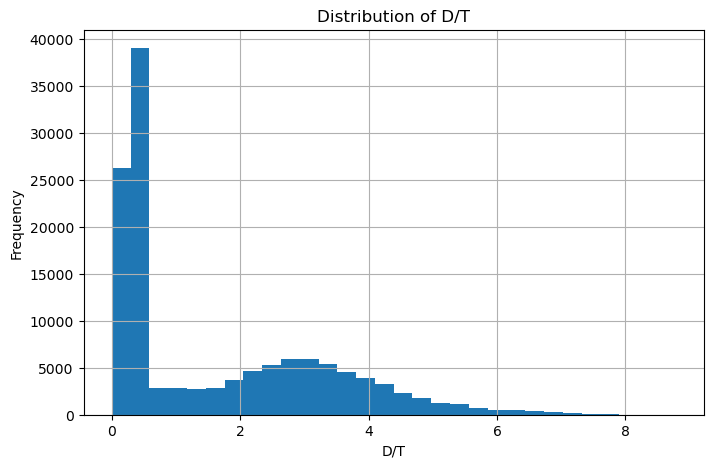

In [18]:
import matplotlib.pyplot as plt
from IPython.display import display

# กัน error ถ้ายังไม่ได้กำหนด target_col
if "target_col" not in globals():
    target_col = "D/T"

# กัน error ถ้ายังไม่มี df_clean
if "df_clean" not in globals():
    raise NameError("ยังไม่มี df_clean กรุณารัน cell แรกของ Step 4 หรือ Step 3 ก่อน")

print("✅ สถิติของค่า D/T")
display(df_clean[target_col].describe().to_frame("D/T"))

plt.figure(figsize=(8, 5))
plt.hist(df_clean[target_col].dropna(), bins=30)
plt.title("Distribution of D/T")
plt.xlabel("D/T")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

### 4.3 ดูค่า D/T ตามเวลา

ตัวอย่างข้อมูลที่ใช้วาดกราฟ


,Time,D/T
808,2026-02-12 13:28:00,1.39
809,2026-02-12 13:29:00,1.35
810,2026-02-12 13:30:00,1.35
811,2026-02-12 13:31:00,1.35
812,2026-02-12 13:32:00,1.34


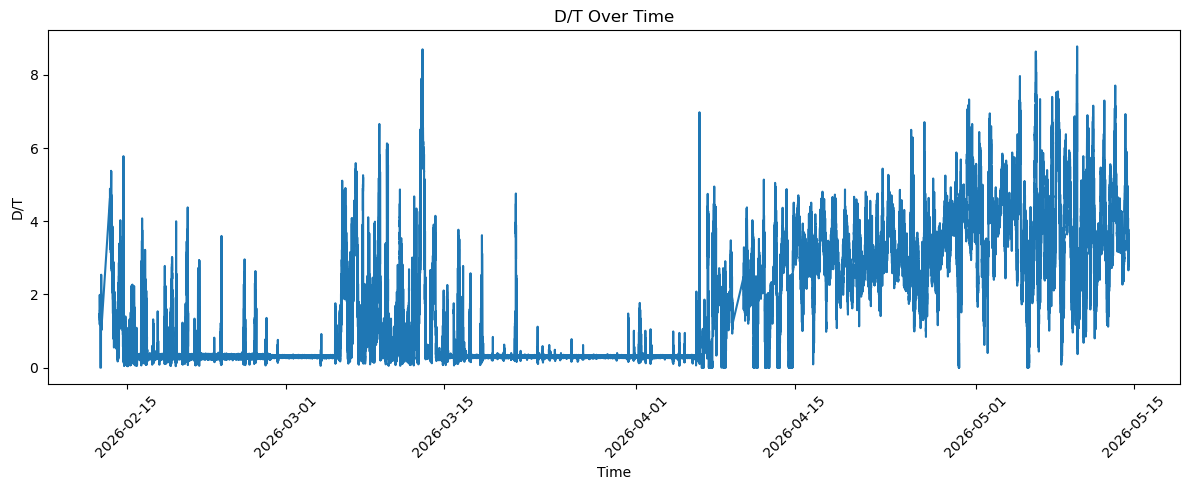

แสดงแนวโน้มค่า D/T ตามเวลาเรียบร้อย


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ถ้ายังไม่มี df_clean ให้โหลดข้อมูลและทำความสะอาดแบบสั้น ๆ ก่อน
if "df_clean" not in globals():
    df = pd.read_csv("Export.csv", skiprows=1)
    df.columns = df.columns.str.strip()

    sensor_cols = [f"Sensor {i}" for i in range(1, 9)]

    numeric_cols = [
        "D/T",
        "Wind Direction",
        "Wind Speed",
        "Temperature",
        "Relative Humidity",
        "PM 2.5",
        "Atmospheric Pressure"
    ] + sensor_cols

    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df_clean = df[
        ~df["Smell Prediction"].astype(str).str.contains("hackathon", case=False, na=False)
    ].copy()

    df_clean = df_clean[~df_clean[sensor_cols].isna().all(axis=1)].copy()

    df_clean = df_clean.dropna(subset=numeric_cols + ["Time"]).copy()

# กำหนด target
target_col = "D/T"

# เรียงข้อมูลตามเวลา
df_time = df_clean.sort_values("Time").copy()

print("ตัวอย่างข้อมูลที่ใช้วาดกราฟ")
display(df_time[["Time", target_col]].head())

plt.figure(figsize=(12, 5))
plt.plot(df_time["Time"], df_time[target_col])
plt.title("D/T Over Time")
plt.xlabel("Time")
plt.ylabel("D/T")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("แสดงแนวโน้มค่า D/T ตามเวลาเรียบร้อย")

### 4.4 ค่าเฉลี่ย D/T แยกตามชั่วโมง

,hour,D/T
0,0,1.671285
1,1,1.606472
2,2,1.562197
3,3,1.581013
4,4,1.732213
5,5,1.955155
6,6,2.200346
7,7,2.341781
8,8,2.273868
9,9,1.927742


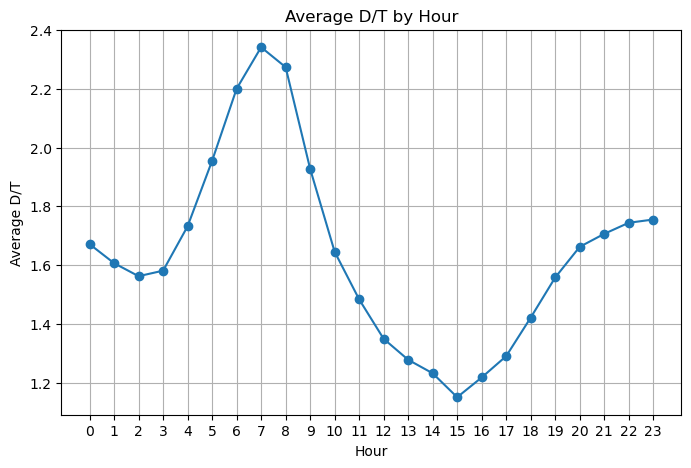

In [20]:
df_clean["hour"] = df_clean["Time"].dt.hour

hourly_dt = df_clean.groupby("hour")[target_col].mean().reset_index()

display(hourly_dt)

plt.figure(figsize=(8, 5))
plt.plot(hourly_dt["hour"], hourly_dt[target_col], marker="o")
plt.title("Average D/T by Hour")
plt.xlabel("Hour")
plt.ylabel("Average D/T")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

### 4.5 หาช่วงเวลาที่ D/T สูงที่สุด

In [21]:
top_dt_cols = [
    "Time",
    target_col,
    "Wind Direction",
    "Wind Speed",
    "Temperature",
    "Relative Humidity",
    "PM 2.5",
    "Atmospheric Pressure"
] + sensor_cols

top_dt = df_clean.sort_values(target_col, ascending=False)[top_dt_cols].head(10)

print("10 แถวที่มีค่า D/T สูงที่สุด")
display(top_dt)

10 แถวที่มีค่า D/T สูงที่สุด


,Time,D/T,Wind Direction,Wind Speed,Temperature,Relative Humidity,PM 2.5,Atmospheric Pressure,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8
123803,2026-05-09 23:26:00,8.78,179.81,0.96,29.11,85.50,45.99,1007.40,107.88,107.88,304.63,33.25,46.95,275.27,326.85,261.67
41917,2026-03-13 02:37:00,8.70,2.70,0.00,28.11,67.06,94.17,1008.00,171.23,171.23,307.63,36.97,27.98,271.03,318.04,263.80
118544,2026-05-06 07:45:00,8.64,239.06,0.00,31.77,70.95,39.61,1007.80,113.64,113.64,317.02,35.90,46.85,272.01,317.77,259.64
41919,2026-03-13 02:39:00,8.57,2.70,0.00,28.07,67.06,93.83,1008.00,165.58,165.58,306.49,36.88,27.49,270.93,318.76,263.44
118545,2026-05-06 07:46:00,8.44,292.15,0.64,31.86,70.71,38.59,1007.80,113.42,113.42,317.03,35.62,47.00,271.44,309.96,259.48
123802,2026-05-09 23:25:00,8.42,173.93,0.50,29.13,85.27,45.88,1007.42,106.16,106.16,302.67,32.63,46.05,273.91,320.00,260.70
118574,2026-05-06 08:15:00,8.41,219.71,0.33,32.45,69.16,41.28,1007.90,116.47,116.47,319.38,36.46,48.40,272.16,304.34,260.80
123799,2026-05-09 23:22:00,8.41,168.43,0.06,29.12,84.81,47.02,1007.50,109.35,109.35,301.07,32.71,46.53,273.67,318.32,260.70
41916,2026-03-13 02:36:00,8.39,2.70,0.00,28.13,66.32,93.67,1008.00,174.06,174.06,304.40,35.88,26.09,269.67,312.83,262.42
41918,2026-03-13 02:38:00,8.38,2.70,0.00,28.09,66.87,91.50,1008.00,163.47,163.47,305.83,36.41,27.14,270.40,315.41,262.63


### 4.6 ความสัมพันธ์ระหว่าง Sensor 1–8 กับ D/T

,correlation_with_D/T
Sensor 5,0.849794
Sensor 3,0.684431
Sensor 1,0.318154
Sensor 2,0.318154
Sensor 8,-0.183736
Sensor 4,0.040722
Sensor 7,-0.022912
Sensor 6,-0.021116


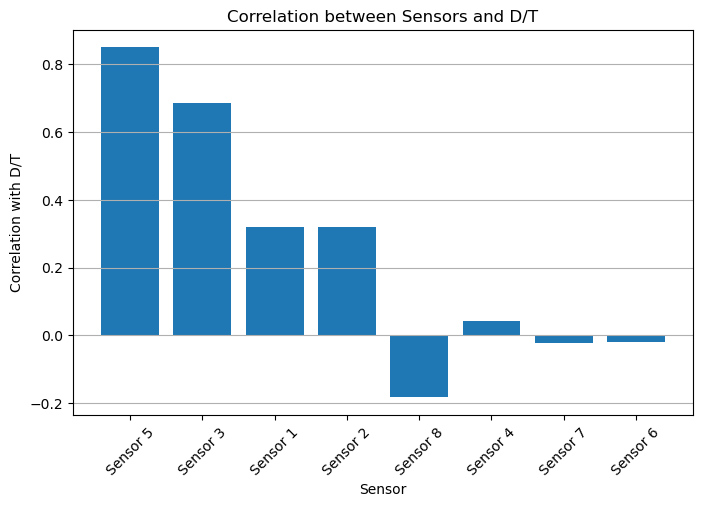

In [22]:
corr_with_dt = df_clean[sensor_cols + [target_col]].corr()[target_col].drop(target_col)
corr_with_dt = corr_with_dt.sort_values(key=lambda x: x.abs(), ascending=False)

display(corr_with_dt.to_frame("correlation_with_D/T"))

plt.figure(figsize=(8, 5))
plt.bar(corr_with_dt.index, corr_with_dt.values)
plt.title("Correlation between Sensors and D/T")
plt.xlabel("Sensor")
plt.ylabel("Correlation with D/T")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

### 4.7 ความสัมพันธ์ระหว่างสภาพอากาศกับ D/T

ความสัมพันธ์ระหว่างสภาพอากาศกับ D/T


,correlation_with_D/T
Relative Humidity,0.285936
PM 2.5,-0.135509
Wind Speed,-0.118960
Atmospheric Pressure,-0.101435
Temperature,-0.043967
Wind Direction,-0.022768


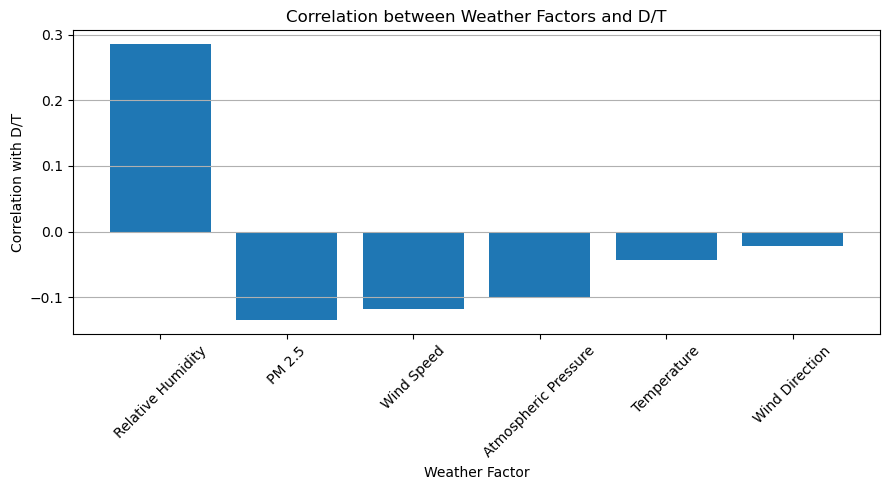

In [23]:
import matplotlib.pyplot as plt
from IPython.display import display

# กัน NameError
target_col = "D/T"

weather_cols = [
    "Wind Direction",
    "Wind Speed",
    "Temperature",
    "Relative Humidity",
    "PM 2.5",
    "Atmospheric Pressure"
]

# คำนวณ correlation ระหว่างสภาพอากาศกับ D/T
weather_corr = df_clean[weather_cols + [target_col]].corr()[target_col].drop(target_col)
weather_corr = weather_corr.sort_values(key=lambda x: x.abs(), ascending=False)

print("ความสัมพันธ์ระหว่างสภาพอากาศกับ D/T")
display(weather_corr.to_frame("correlation_with_D/T"))

plt.figure(figsize=(9, 5))
plt.bar(weather_corr.index, weather_corr.values)
plt.title("Correlation between Weather Factors and D/T")
plt.xlabel("Weather Factor")
plt.ylabel("Correlation with D/T")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### 4.8 Heatmap ความสัมพันธ์ของตัวแปรหลัก

Correlation Matrix ของตัวแปรหลัก


,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Wind Direction,Wind Speed,Temperature,Relative Humidity,PM 2.5,Atmospheric Pressure,D/T
Sensor 1,1.000000,1.000000,0.226554,0.323727,0.239017,0.261804,0.206617,0.118601,0.025092,-0.118726,0.143229,-0.086310,0.310020,-0.005325,0.318154
Sensor 2,1.000000,1.000000,0.226554,0.323727,0.239017,0.261804,0.206617,0.118601,0.025092,-0.118726,0.143229,-0.086310,0.310020,-0.005325,0.318154
Sensor 3,0.226554,0.226554,1.000000,0.105576,0.560619,0.168599,0.265545,0.168400,-0.012463,-0.124078,-0.276082,0.476494,-0.121611,-0.106396,0.684431
Sensor 4,0.323727,0.323727,0.105576,1.000000,-0.026760,0.456505,0.402306,0.481348,0.137440,-0.233223,0.497920,-0.519844,0.355714,0.070484,0.040722
Sensor 5,0.239017,0.239017,0.560619,-0.026760,1.000000,-0.155310,-0.286162,-0.370220,0.039389,-0.035146,0.079452,0.222091,-0.241488,-0.215435,0.849794
Sensor 6,0.261804,0.261804,0.168599,0.456505,-0.155310,1.000000,0.696380,0.944366,0.050199,-0.015158,0.048778,0.141121,0.194692,0.061653,-0.021116
Sensor 7,0.206617,0.206617,0.265545,0.402306,-0.286162,0.696380,1.000000,0.781673,0.019813,-0.339837,-0.387259,0.293721,0.280953,0.297617,-0.022912
Sensor 8,0.118601,0.118601,0.168400,0.481348,-0.370220,0.944366,0.781673,1.000000,0.038432,-0.041733,-0.024520,0.123974,0.228652,0.112704,-0.183736
Wind Direction,0.025092,0.025092,-0.012463,0.137440,0.039389,0.050199,0.019813,0.038432,1.000000,-0.101873,0.096894,-0.072819,0.010296,-0.065448,-0.022768
Wind Speed,-0.118726,-0.118726,-0.124078,-0.233223,-0.035146,-0.015158,-0.339837,-0.041733,-0.101873,1.000000,0.166886,0.003884,-0.107952,-0.289672,-0.118960


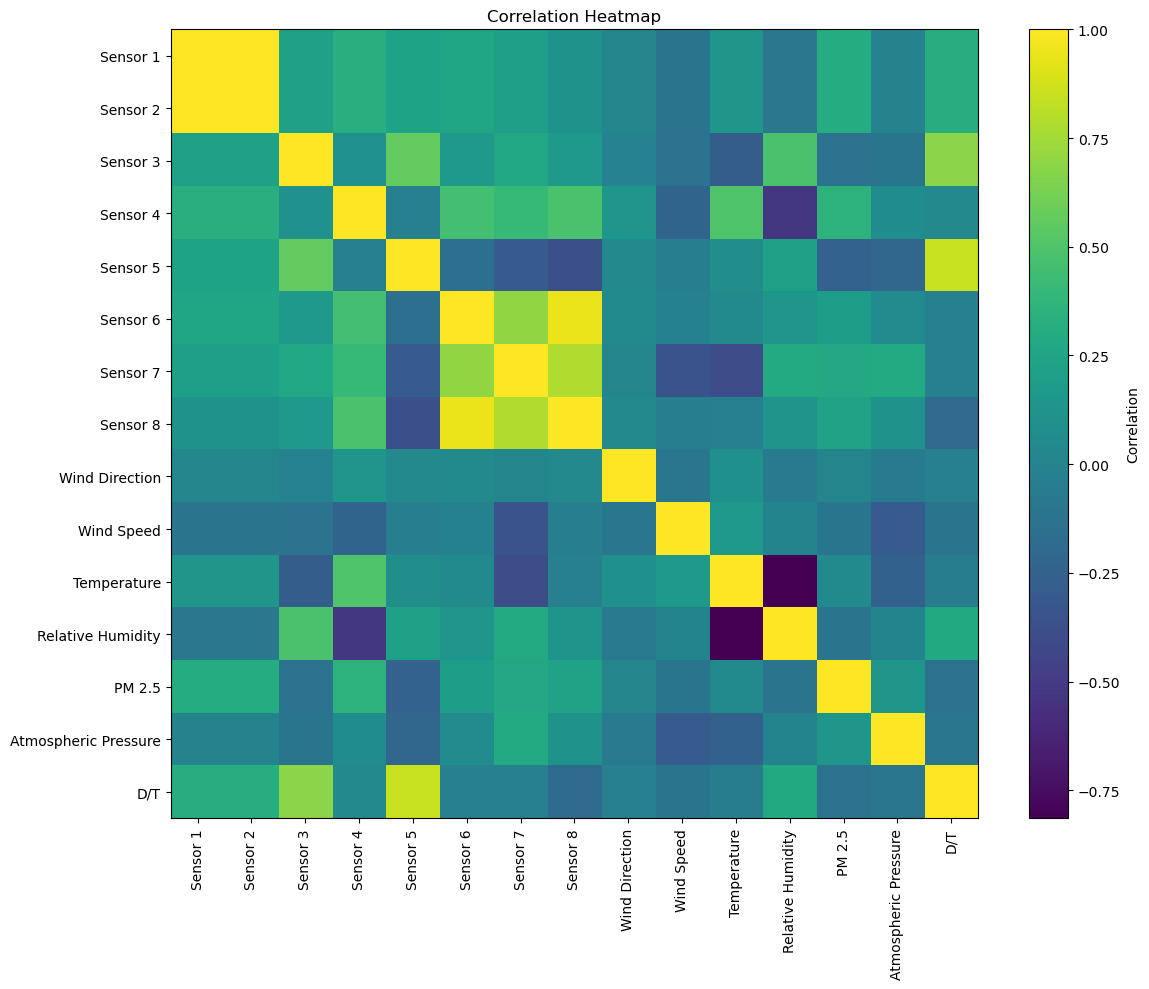

In [24]:
import matplotlib.pyplot as plt
from IPython.display import display

# กัน NameError
target_col = "D/T"
sensor_cols = [f"Sensor {i}" for i in range(1, 9)]

weather_cols = [
    "Wind Direction",
    "Wind Speed",
    "Temperature",
    "Relative Humidity",
    "PM 2.5",
    "Atmospheric Pressure"
]

main_cols = sensor_cols + weather_cols + [target_col]

# คำนวณ correlation matrix
corr_matrix = df_clean[main_cols].corr()

print("Correlation Matrix ของตัวแปรหลัก")
display(corr_matrix)

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### 4.9 แบ่งระดับความเข้มกลิ่นจากค่า D/T

,D/T Level,count
0,Low,123428
1,Medium,5045


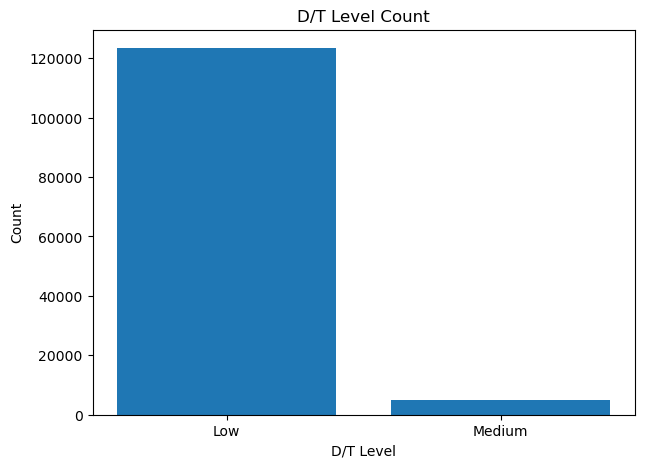

In [25]:
def smell_level(dt):
    if dt < 5:
        return "Low"
    elif dt < 15:
        return "Medium"
    else:
        return "High"

df_clean["D/T Level"] = df_clean[target_col].apply(smell_level)

level_count = df_clean["D/T Level"].value_counts().reset_index()
level_count.columns = ["D/T Level", "count"]

display(level_count)

plt.figure(figsize=(7, 5))
plt.bar(level_count["D/T Level"], level_count["count"])
plt.title("D/T Level Count")
plt.xlabel("D/T Level")
plt.ylabel("Count")
plt.show()

### 4.10 สรุปผล Data Exploration

In [26]:
# กัน error ถ้ายังไม่ได้รัน 4.6
corr_with_dt = df_clean[sensor_cols + [target_col]].corr()[target_col].drop(target_col)
corr_with_dt = corr_with_dt.sort_values(key=lambda x: x.abs(), ascending=False)

max_dt_row = df_clean.loc[df_clean[target_col].idxmax()]

top_sensor_corr = corr_with_dt.index[0]
top_sensor_corr_value = corr_with_dt.iloc[0]

explore_summary = pd.DataFrame({
    "รายการ": [
        "ค่า D/T ต่ำสุด",
        "ค่า D/T สูงสุด",
        "ค่า D/T เฉลี่ย",
        "เวลาที่ D/T สูงสุด",
        "Sensor ที่สัมพันธ์กับ D/T มากที่สุด",
        "ค่า correlation ของ Sensor นั้น"
    ],
    "ผลลัพธ์": [
        round(df_clean[target_col].min(), 3),
        round(df_clean[target_col].max(), 3),
        round(df_clean[target_col].mean(), 3),
        max_dt_row["Time"],
        top_sensor_corr,
        round(top_sensor_corr_value, 4)
    ]
})

display(explore_summary)

,รายการ,ผลลัพธ์
0,ค่า D/T ต่ำสุด,0.0
1,ค่า D/T สูงสุด,8.78
2,ค่า D/T เฉลี่ย,1.638
3,เวลาที่ D/T สูงสุด,2026-05-09 23:26:00
4,Sensor ที่สัมพันธ์กับ D/T มากที่สุด,Sensor 5
5,ค่า correlation ของ Sensor นั้น,0.8498


### สรุป Step 4

จากการสำรวจข้อมูลหลังทำความสะอาด พบว่าเราสามารถดูแนวโน้มของค่า D/T ตามเวลา ตรวจสอบช่วงเวลาที่กลิ่นมีความเข้มสูง และวิเคราะห์ความสัมพันธ์ระหว่างค่า Sensor 1–8 รวมถึงปัจจัยสภาพอากาศกับค่า D/T ได้

ผลจากขั้นตอนนี้ช่วยให้เข้าใจข้อมูลมากขึ้น และใช้เป็นพื้นฐานสำหรับ Step 5 — Data Modeling เพื่อสร้างโมเดลประเมินความเข้มกลิ่นจากค่าของเซ็นเซอร์

## Step 5 — Data Modeling

ขั้นตอนนี้เป็นการสร้างโมเดลเพื่อประเมินค่า D/T หรือความเข้มกลิ่นจากค่าของ Sensor 1–8 และปัจจัยสภาพอากาศ

ในงานนี้ใช้ D/T เป็น target เพราะเป็นค่าตัวเลขที่แสดงระดับความเข้มของกลิ่น จึงเหมาะกับการทำ Regression Model

### 5.1 เตรียมข้อมูลสำหรับ Modeling

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# ถ้ายังไม่มี df_clean ให้โหลดและ clean แบบรวบรัด
if "df_clean" not in globals():
    print("ยังไม่มี df_clean → กำลังโหลดและเตรียมข้อมูลจาก Export.csv")

    df = pd.read_csv("Export.csv", skiprows=1)
    df.columns = df.columns.str.strip()

    sensor_cols = [f"Sensor {i}" for i in range(1, 9)]

    weather_cols = [
        "Wind Direction",
        "Wind Speed",
        "Temperature",
        "Relative Humidity",
        "PM 2.5",
        "Atmospheric Pressure"
    ]

    target_col = "D/T"
    numeric_cols = [target_col] + weather_cols + sensor_cols

    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # ลบ marker hackathon
    df_clean = df[
        ~df["Smell Prediction"].astype(str).str.contains("hackathon", case=False, na=False)
    ].copy()

    # ลบแถวที่ Sensor ว่างทั้งหมด
    df_clean = df_clean[~df_clean[sensor_cols].isna().all(axis=1)].copy()

else:
    print("ใช้ df_clean จาก Step 3/4")

# กำหนดตัวแปรสำคัญใหม่อีกรอบ กัน NameError
sensor_cols = [f"Sensor {i}" for i in range(1, 9)]

weather_cols = [
    "Wind Direction",
    "Wind Speed",
    "Temperature",
    "Relative Humidity",
    "PM 2.5",
    "Atmospheric Pressure"
]

target_col = "D/T"

# สร้าง feature จากเวลา
df_clean["Time"] = pd.to_datetime(df_clean["Time"], errors="coerce")
df_clean["hour"] = df_clean["Time"].dt.hour
df_clean["dayofweek"] = df_clean["Time"].dt.dayofweek
df_clean["month"] = df_clean["Time"].dt.month

time_cols = ["hour", "dayofweek", "month"]

feature_cols = sensor_cols + weather_cols + time_cols

# ลบแถวที่ feature หรือ target เป็นค่าว่าง
model_df = df_clean.dropna(subset=feature_cols + [target_col]).copy()

X = model_df[feature_cols]
y = model_df[target_col]

print("เตรียมข้อมูลสำหรับ Modeling เรียบร้อย")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

display(X.head())
display(y.head().to_frame("D/T"))

ใช้ df_clean จาก Step 3/4
เตรียมข้อมูลสำหรับ Modeling เรียบร้อย
X shape: (128473, 17)
y shape: (128473,)


,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Wind Direction,Wind Speed,Temperature,Relative Humidity,PM 2.5,Atmospheric Pressure,hour,dayofweek,month
808,82.00,82.00,415.00,56.00,22.00,243.00,264.0,250.06,210.9,0.0,24.51,40.33,47.50,1011.1,13,3,2
809,82.00,82.00,414.74,56.00,22.00,242.98,264.0,250.00,210.9,0.0,24.50,40.31,47.00,1011.0,13,3,2
810,82.55,82.55,414.00,55.69,22.00,242.92,264.0,250.00,210.9,0.0,24.55,40.20,46.33,1011.0,13,3,2
811,82.99,82.99,413.97,55.00,21.99,242.66,264.0,250.00,210.9,0.0,24.56,40.06,48.00,1011.0,13,3,2
812,83.00,83.00,413.90,55.00,21.75,242.92,264.0,250.00,210.9,0.0,24.56,40.04,48.50,1011.0,13,3,2


,D/T
808,1.39
809,1.35
810,1.35
811,1.35
812,1.34


### 5.2 แบ่งข้อมูล Train/Test

In [28]:
from sklearn.model_selection import train_test_split

# ใช้การแบ่งแบบตามเวลา: 80% แรก train, 20% หลัง test
model_df = model_df.sort_values("Time").copy()

X = model_df[feature_cols]
y = model_df[target_col]

split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("แบ่งข้อมูล Train/Test เรียบร้อย")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

แบ่งข้อมูล Train/Test เรียบร้อย
X_train: (102778, 17)
X_test : (25695, 17)
y_train: (102778,)
y_test : (25695,)


### 5.3 สร้างโมเดล Linear Regression

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Result")
print(f"MAE : {linear_mae:.4f}")
print(f"RMSE: {linear_rmse:.4f}")
print(f"R²  : {linear_r2:.4f}")

Linear Regression Result
MAE : 1.3971
RMSE: 1.6392
R²  : -0.4931


### 5.4 สร้างโมเดล Random Forest

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Result")
print(f"MAE : {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R²  : {rf_r2:.4f}")

Random Forest Result
MAE : 0.4144
RMSE: 0.5601
R²  : 0.8257


### 5.5 เปรียบเทียบผลลัพธ์ของโมเดล

In [31]:
model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2": [linear_r2, rf_r2]
})

display(model_results)

best_model_name = model_results.sort_values("RMSE").iloc[0]["Model"]

print(f"โมเดลที่ให้ค่า RMSE ต่ำที่สุดคือ: {best_model_name}")

,Model,MAE,RMSE,R2
0,Linear Regression,1.397092,1.639198,-0.493148
1,Random Forest,0.414358,0.560099,0.825671


โมเดลที่ให้ค่า RMSE ต่ำที่สุดคือ: Random Forest


### 5.6 กราฟเปรียบเทียบค่าจริงกับค่าที่โมเดลทำนาย

,Actual D/T,Predicted D/T
0,2.83,2.8888
1,3.02,3.0306
2,3.33,3.2152
3,2.89,2.9016
4,2.87,2.9142
5,3.11,3.1682
6,2.95,2.9864
7,3.23,3.1884
8,3.51,3.4678
9,3.17,3.1756


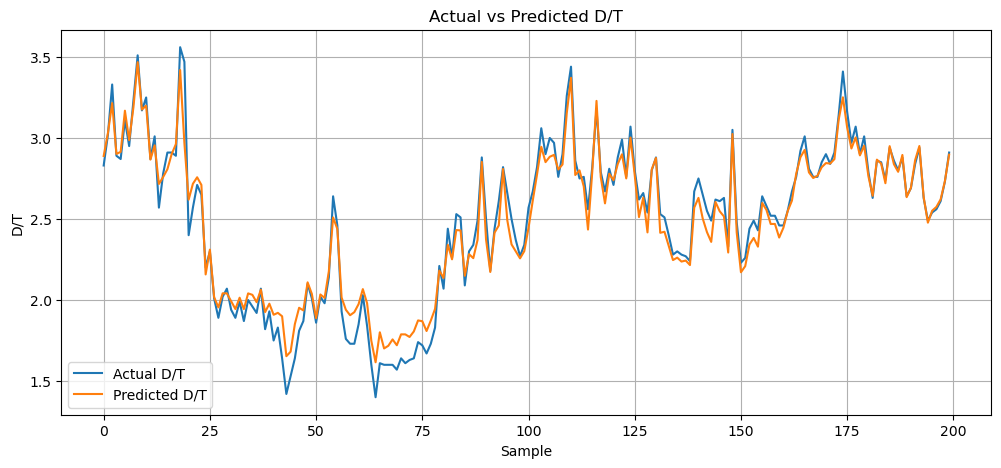

In [32]:
# เลือก prediction จากโมเดลที่ดีที่สุด
if best_model_name == "Random Forest":
    best_pred = y_pred_rf
else:
    best_pred = y_pred_linear

compare_df = pd.DataFrame({
    "Actual D/T": y_test.values,
    "Predicted D/T": best_pred
})

display(compare_df.head(20))

plt.figure(figsize=(12, 5))
plt.plot(compare_df["Actual D/T"].values[:200], label="Actual D/T")
plt.plot(compare_df["Predicted D/T"].values[:200], label="Predicted D/T")
plt.title("Actual vs Predicted D/T")
plt.xlabel("Sample")
plt.ylabel("D/T")
plt.legend()
plt.grid(True)
plt.show()

### 5.7 ดู Feature Importance ของ Random Forest

,Feature,Importance
4,Sensor 5,0.651206
2,Sensor 3,0.127351
6,Sensor 7,0.106802
13,Atmospheric Pressure,0.027566
16,month,0.017076
5,Sensor 6,0.010809
7,Sensor 8,0.009411
15,dayofweek,0.008403
12,PM 2.5,0.007346
8,Wind Direction,0.006849


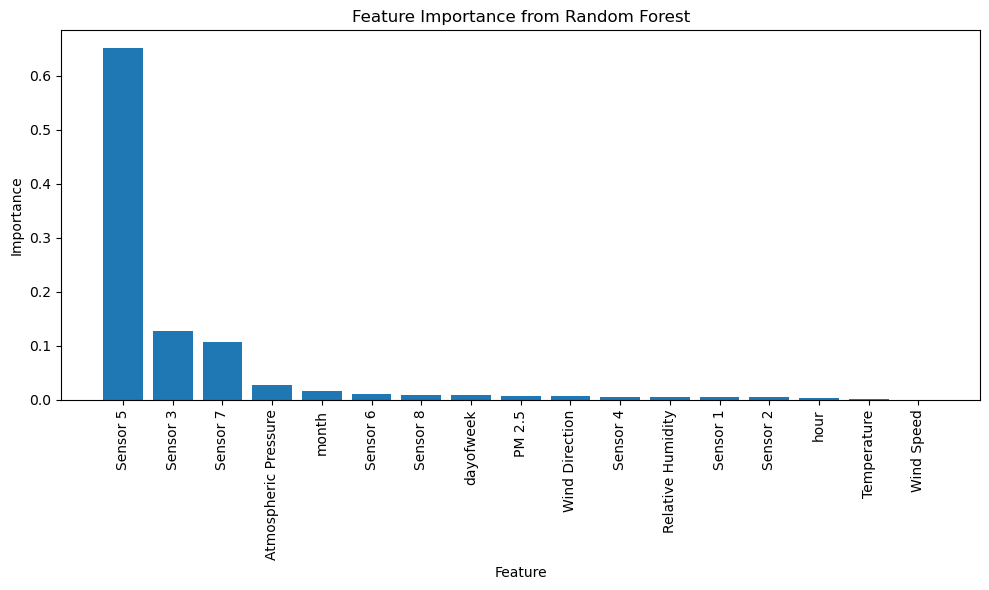

In [33]:
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values("Importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(10, 6))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance from Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 5.8 สรุปผล Data Modeling

In [34]:
summary_model = pd.DataFrame({
    "รายการ": [
        "Target ที่ใช้ทำนาย",
        "จำนวน Feature",
        "จำนวนข้อมูล Train",
        "จำนวนข้อมูล Test",
        "โมเดลที่เปรียบเทียบ",
        "โมเดลที่ดีที่สุด",
        "เกณฑ์ที่ใช้เลือก"
    ],
    "ผลลัพธ์": [
        target_col,
        len(feature_cols),
        len(X_train),
        len(X_test),
        "Linear Regression, Random Forest",
        best_model_name,
        "RMSE ต่ำที่สุด"
    ]
})

display(summary_model)

,รายการ,ผลลัพธ์
0,Target ที่ใช้ทำนาย,D/T
1,จำนวน Feature,17
2,จำนวนข้อมูล Train,102778
3,จำนวนข้อมูล Test,25695
4,โมเดลที่เปรียบเทียบ,"Linear Regression, Random Forest"
5,โมเดลที่ดีที่สุด,Random Forest
6,เกณฑ์ที่ใช้เลือก,RMSE ต่ำที่สุด


### สรุป Step 5

ในขั้นตอน Data Modeling เราใช้ค่า Sensor 1–8 ปัจจัยสภาพอากาศ และข้อมูลเวลาเป็น input เพื่อทำนายค่า D/T ซึ่งเป็นค่าความเข้มกลิ่น

โมเดลที่ใช้เปรียบเทียบคือ Linear Regression และ Random Forest โดยประเมินผลด้วยค่า MAE, RMSE และ R² จากนั้นเลือกโมเดลที่มีค่า RMSE ต่ำที่สุดเป็นโมเดลที่เหมาะสมที่สุดสำหรับงานนี้

### 6.1 เตรียมข้อมูลและโมเดลสำหรับ Presentation

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ถ้ายังไม่มี model_df หรือ best_model_name ให้สร้างใหม่แบบรวบรัด
if "model_df" not in globals() or "best_model_name" not in globals():
    print("ยังไม่มีผลจาก Step 5 → กำลังสร้างข้อมูลและเทรนโมเดลใหม่แบบรวบรัด")

    df = pd.read_csv("Export.csv", skiprows=1)
    df.columns = df.columns.str.strip()

    sensor_cols = [f"Sensor {i}" for i in range(1, 9)]

    weather_cols = [
        "Wind Direction",
        "Wind Speed",
        "Temperature",
        "Relative Humidity",
        "PM 2.5",
        "Atmospheric Pressure"
    ]

    target_col = "D/T"
    numeric_cols = [target_col] + weather_cols + sensor_cols

    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df_clean = df[
        ~df["Smell Prediction"].astype(str).str.contains("hackathon", case=False, na=False)
    ].copy()

    df_clean = df_clean[~df_clean[sensor_cols].isna().all(axis=1)].copy()

    df_clean["hour"] = df_clean["Time"].dt.hour
    df_clean["dayofweek"] = df_clean["Time"].dt.dayofweek
    df_clean["month"] = df_clean["Time"].dt.month

    time_cols = ["hour", "dayofweek", "month"]
    feature_cols = sensor_cols + weather_cols + time_cols

    model_df = df_clean.dropna(subset=feature_cols + [target_col]).copy()
    model_df = model_df.sort_values("Time").copy()

    X = model_df[feature_cols]
    y = model_df[target_col]

    split_index = int(len(model_df) * 0.8)

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    y_pred_linear = linear_model.predict(X_test)

    rf_model = RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)

    linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
    rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

    if rf_rmse <= linear_rmse:
        best_model_name = "Random Forest"
        best_model = rf_model
        best_pred = y_pred_rf
    else:
        best_model_name = "Linear Regression"
        best_model = linear_model
        best_pred = y_pred_linear

else:
    print("ใช้ผลจาก Step 5 ต่อได้เลย")

    if best_model_name == "Random Forest":
        best_model = rf_model
        best_pred = y_pred_rf
    else:
        best_model = linear_model
        best_pred = y_pred_linear

print("พร้อมสำหรับ Step 6 แล้ว")
print("Best model:", best_model_name)
print("Test data:", len(y_test), "rows")

ใช้ผลจาก Step 5 ต่อได้เลย
พร้อมสำหรับ Step 6 แล้ว
Best model: Random Forest
Test data: 25695 rows


### 6.2-6.4 สรุปผลลัพธ์ของโมเดล, กราฟ Actual D/T เทียบกับ Predicted D/T , บันทึกผลการทำนายเป็นไฟล์ CSV

In [36]:
# อันนี้เป็นเวอร์ชัน self-contained กัน IndexError / NameError

import pandas as pd
import numpy as np
from IPython.display import display

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------
# 1) โหลดข้อมูล
# -------------------------

df = pd.read_csv("Export.csv", skiprows=1)
df.columns = df.columns.str.strip()

sensor_cols = [f"Sensor {i}" for i in range(1, 9)]

weather_cols = [
    "Wind Direction",
    "Wind Speed",
    "Temperature",
    "Relative Humidity",
    "PM 2.5",
    "Atmospheric Pressure"
]

target_col = "D/T"
numeric_cols = [target_col] + weather_cols + sensor_cols

# -------------------------
# 2) เตรียมข้อมูลเบื้องต้น
# -------------------------

df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ลบ marker ที่ไม่ใช่ข้อมูลจริง
df_clean = df[
    ~df["Smell Prediction"].astype(str).str.contains("hackathon", case=False, na=False)
].copy()

# ลบแถวที่ sensor ว่างทั้งหมด
df_clean = df_clean[~df_clean[sensor_cols].isna().all(axis=1)].copy()

# สร้าง feature จากเวลา
df_clean["hour"] = df_clean["Time"].dt.hour
df_clean["dayofweek"] = df_clean["Time"].dt.dayofweek
df_clean["month"] = df_clean["Time"].dt.month

time_cols = ["hour", "dayofweek", "month"]
feature_cols = sensor_cols + weather_cols + time_cols

# ลบแถวที่ feature หรือ target มีค่าว่าง
model_df = df_clean.dropna(subset=feature_cols + [target_col]).copy()
model_df = model_df.sort_values("Time").copy()

# -------------------------
# 3) แยก X, y และ Train/Test
# -------------------------

X = model_df[feature_cols]
y = model_df[target_col]

split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# -------------------------
# 4) สร้างและเทรนโมเดล
# -------------------------

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

rf_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# -------------------------
# 5) ประเมินผลโมเดล
# -------------------------

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2": [linear_r2, rf_r2]
})

model_results = model_results.sort_values("RMSE").reset_index(drop=True)

# -------------------------
# 6) เลือกโมเดลที่ดีที่สุด
# -------------------------

best_model_name = model_results.loc[0, "Model"]

if best_model_name == "Random Forest":
    best_model = rf_model
    best_pred = y_pred_rf
else:
    best_model = linear_model
    best_pred = y_pred_linear

presentation_summary = pd.DataFrame({
    "รายการ": [
        "โมเดลที่เลือกใช้",
        "Target",
        "จำนวนข้อมูล Train",
        "จำนวนข้อมูล Test",
        "MAE",
        "RMSE",
        "R²"
    ],
    "ผลลัพธ์": [
        best_model_name,
        target_col,
        len(y_train),
        len(y_test),
        round(model_results.loc[0, "MAE"], 4),
        round(model_results.loc[0, "RMSE"], 4),
        round(model_results.loc[0, "R2"], 4)
    ]
})

print("ผลการเปรียบเทียบโมเดล")
display(model_results)

print("สรุปโมเดลที่เลือกใช้")
display(presentation_summary)

print("สร้างตัวแปรสำหรับ 6.3 และ 6.4 เรียบร้อย")
print("ตัวแปรที่สร้างแล้ว: best_model, best_pred, model_df, X_train, X_test, y_test")

ผลการเปรียบเทียบโมเดล


,Model,MAE,RMSE,R2
0,Random Forest,0.391634,0.534194,0.841377
1,Linear Regression,1.389639,1.635504,-0.486869


สรุปโมเดลที่เลือกใช้


,รายการ,ผลลัพธ์
0,โมเดลที่เลือกใช้,Random Forest
1,Target,D/T
2,จำนวนข้อมูล Train,103936
3,จำนวนข้อมูล Test,25984
4,MAE,0.3916
5,RMSE,0.5342
6,R²,0.8414


สร้างตัวแปรสำหรับ 6.3 และ 6.4 เรียบร้อย
ตัวแปรที่สร้างแล้ว: best_model, best_pred, model_df, X_train, X_test, y_test


### 6.5 บันทึกโมเดลที่ดีที่สุด

In [37]:
import pandas as pd
import joblib
from IPython.display import display

# ต้องรัน 6.2 ก่อน เพราะ 6.2 สร้าง best_model / best_model_name
if "best_model" not in globals():
    raise NameError("ยังไม่มี best_model กรุณารัน 6.2 ก่อน")

if "best_model_name" not in globals():
    best_model_name = "Unknown Model"

# กันตัวแปรหาย
if "sensor_cols" not in globals():
    sensor_cols = [f"Sensor {i}" for i in range(1, 9)]

if "weather_cols" not in globals():
    weather_cols = [
        "Wind Direction",
        "Wind Speed",
        "Temperature",
        "Relative Humidity",
        "PM 2.5",
        "Atmospheric Pressure"
    ]

if "target_col" not in globals():
    target_col = "D/T"

if "feature_cols" not in globals():
    time_cols = ["hour", "dayofweek", "month"]
    feature_cols = sensor_cols + weather_cols + time_cols

model_filename = "best_odor_model.pkl"

model_package = {
    "model": best_model,
    "model_name": best_model_name,
    "feature_cols": feature_cols,
    "target_col": target_col
}

joblib.dump(model_package, model_filename)

save_summary = pd.DataFrame({
    "รายการ": [
        "ชื่อไฟล์โมเดล",
        "โมเดลที่บันทึก",
        "Target",
        "จำนวน Feature"
    ],
    "ผลลัพธ์": [
        model_filename,
        best_model_name,
        target_col,
        len(feature_cols)
    ]
})

print("บันทึกโมเดลเรียบร้อย")
display(save_summary)

บันทึกโมเดลเรียบร้อย


,รายการ,ผลลัพธ์
0,ชื่อไฟล์โมเดล,best_odor_model.pkl
1,โมเดลที่บันทึก,Random Forest
2,Target,D/T
3,จำนวน Feature,17


### 6.6 Automation: สร้าง Function สำหรับทำนายข้อมูลใหม่

In [38]:
import pandas as pd
import joblib
from IPython.display import display

# ถ้ายังไม่มี best_model ให้โหลดจากไฟล์ที่บันทึกไว้ใน 6.5
if "best_model" not in globals():
    model_package = joblib.load("best_odor_model.pkl")
    best_model = model_package["model"]
    best_model_name = model_package["model_name"]
    feature_cols = model_package["feature_cols"]
    target_col = model_package["target_col"]

def predict_odor_intensity(new_data):
    """
    รับข้อมูลใหม่เป็น DataFrame แล้วทำนายค่า D/T
    """

    new_data = new_data.copy()
    new_data.columns = new_data.columns.str.strip()

    # แปลง Time และสร้าง feature เวลา
    new_data["Time"] = pd.to_datetime(new_data["Time"], errors="coerce")
    new_data["hour"] = new_data["Time"].dt.hour
    new_data["dayofweek"] = new_data["Time"].dt.dayofweek
    new_data["month"] = new_data["Time"].dt.month

    # เช็กว่ามี feature ครบไหม
    missing_cols = [col for col in feature_cols if col not in new_data.columns]

    if len(missing_cols) > 0:
        raise ValueError(f"ข้อมูลใหม่ขาดคอลัมน์เหล่านี้: {missing_cols}")

    # แปลง feature เป็นตัวเลข
    for col in feature_cols:
        new_data[col] = pd.to_numeric(new_data[col], errors="coerce")

    X_new = new_data[feature_cols]

    # กัน error ถ้ามีค่าว่างในข้อมูลใหม่
    if X_new.isna().sum().sum() > 0:
        print("พบค่าว่างในข้อมูลใหม่ กรุณาตรวจสอบก่อนทำนาย")
        display(X_new.isna().sum().to_frame("missing_count"))
        raise ValueError("ข้อมูลใหม่ยังมีค่าว่างใน feature ที่ใช้ทำนาย")

    new_data["Predicted D/T"] = best_model.predict(X_new)

    return new_data

# ทดลองใช้ข้อมูล 5 แถวล่าสุดจาก model_df
if "model_df" not in globals():
    raise NameError("ยังไม่มี model_df กรุณารัน 6.2 ก่อน")

new_sample = model_df.tail(5).copy()
prediction_sample = predict_odor_intensity(new_sample)

print("ตัวอย่างการทำนายข้อมูลใหม่")
display(prediction_sample[["Time", "D/T", "Predicted D/T"]])

ตัวอย่างการทำนายข้อมูลใหม่


,Time,D/T,Predicted D/T
130338,2026-05-14 12:27:00,3.51,3.1432
130339,2026-05-14 12:28:00,2.99,2.5332
130340,2026-05-14 12:29:00,3.32,2.9096
130341,2026-05-14 12:30:00,3.12,2.6444
130342,2026-05-14 12:31:00,2.99,2.5694


### 6.7 Automation: แจ้งเตือนระดับกลิ่นจากค่าที่ทำนาย

In [39]:
import pandas as pd
from IPython.display import display

# ต้องรัน 6.6 ก่อน เพื่อให้มี prediction_sample
if "prediction_sample" not in globals():
    raise NameError("ยังไม่มี prediction_sample กรุณารัน 6.6 ก่อน")

def odor_warning_level(predicted_dt):
    """
    แปลงค่า Predicted D/T เป็นระดับแจ้งเตือน
    เกณฑ์นี้เป็นตัวอย่างสำหรับนำเสนอในโปรเจกต์
    """

    if predicted_dt < 5:
        return "Low"
    elif predicted_dt < 15:
        return "Medium"
    else:
        return "High"

prediction_sample["Warning Level"] = prediction_sample["Predicted D/T"].apply(odor_warning_level)

print("ตัวอย่างระบบแจ้งเตือนระดับกลิ่น")
display(prediction_sample[["Time", "D/T", "Predicted D/T", "Warning Level"]])

# บันทึกตัวอย่างผลแจ้งเตือน
warning_filename = "odor_warning_sample.csv"

prediction_sample[[
    "Time",
    "D/T",
    "Predicted D/T",
    "Warning Level"
]].to_csv(warning_filename, index=False)

print(f"บันทึกไฟล์ตัวอย่างแจ้งเตือนเรียบร้อย: {warning_filename}")

ตัวอย่างระบบแจ้งเตือนระดับกลิ่น


,Time,D/T,Predicted D/T,Warning Level
130338,2026-05-14 12:27:00,3.51,3.1432,Low
130339,2026-05-14 12:28:00,2.99,2.5332,Low
130340,2026-05-14 12:29:00,3.32,2.9096,Low
130341,2026-05-14 12:30:00,3.12,2.6444,Low
130342,2026-05-14 12:31:00,2.99,2.5694,Low


บันทึกไฟล์ตัวอย่างแจ้งเตือนเรียบร้อย: odor_warning_sample.csv


### สรุป Step 6

ในขั้นตอน Presentation and Automation เราได้นำเสนอผลลัพธ์ของโมเดลผ่านตารางและกราฟเปรียบเทียบค่า Actual D/T กับ Predicted D/T

นอกจากนี้ยังบันทึกผลการทำนายเป็นไฟล์ .csv และบันทึกโมเดลที่ดีที่สุดเป็นไฟล์ .pkl เพื่อให้สามารถนำกลับมาใช้งานต่อได้ โดยไม่จำเป็นต้องเทรนโมเดลใหม่ทุกครั้ง

ส่วน Automation ได้สร้าง function สำหรับรับข้อมูล sensor ใหม่ แล้วทำนายค่า D/T อัตโนมัติ พร้อมแปลงผลลัพธ์เป็นระดับการแจ้งเตือนกลิ่น เช่น Low, Medium และ High

## Conclusion

จากกระบวนการ Data Science Process ทั้ง 6 ขั้นตอน เราได้พัฒนาแนวทางสำหรับการประเมินความเข้มกลิ่นจากข้อมูลเซ็นเซอร์ของระบบ e-nose โดยเริ่มจากการกำหนดเป้าหมายของงาน คือการใช้ข้อมูลจาก Sensor 1–8 ร่วมกับปัจจัยสภาพอากาศ เพื่อประเมินค่า D/T ซึ่งเป็นค่าที่ใช้แทนระดับความเข้มของกลิ่น

ในขั้นตอน Retrieving Data เราได้นำข้อมูลจากไฟล์ Export.csv มาใช้เป็นชุดข้อมูลหลัก จากนั้นในขั้นตอน Data Preparation ได้ทำความสะอาดข้อมูล เช่น การแปลงชนิดข้อมูล การลบข้อมูลที่ไม่สมบูรณ์ การลบ marker ที่ไม่ใช่ข้อมูลจริง และการเตรียม feature ที่จำเป็นสำหรับการวิเคราะห์และสร้างโมเดล

หลังจากนั้นในขั้นตอน Data Exploration เราได้สำรวจข้อมูลเพื่อดูแนวโน้มของค่า D/T ตามเวลา ตรวจสอบช่วงที่ค่าความเข้มกลิ่นสูง และวิเคราะห์ความสัมพันธ์ระหว่างค่าจากเซ็นเซอร์ สภาพอากาศ และค่า D/T ซึ่งช่วยให้เข้าใจลักษณะของข้อมูลก่อนนำไปสร้างโมเดล

ในขั้นตอน Data Modeling เราได้สร้างโมเดลเพื่อทำนายค่า D/T โดยใช้ข้อมูลจากเซ็นเซอร์ สภาพอากาศ และข้อมูลเวลาเป็น input จากนั้นเปรียบเทียบผลลัพธ์ของโมเดลด้วยค่า MAE, RMSE และ R² เพื่อเลือกโมเดลที่เหมาะสมที่สุด

สุดท้ายในขั้นตอน Presentation and Automation เราได้นำเสนอผลลัพธ์ของโมเดลผ่านตาราง กราฟเปรียบเทียบค่าจริงกับค่าที่โมเดลทำนาย และบันทึกผลลัพธ์ออกมาเป็นไฟล์ .csv รวมถึงสร้างฟังก์ชันสำหรับทำนายค่า D/T จากข้อมูลใหม่ และแปลงผลลัพธ์เป็นระดับการแจ้งเตือนกลิ่น เช่น Low, Medium และ High

โดยสรุป งานนี้แสดงให้เห็นว่าข้อมูลจากระบบ e-nose สามารถนำมาวิเคราะห์และสร้างโมเดลเพื่อช่วยประเมินความเข้มกลิ่นได้ ซึ่งสามารถนำไปต่อยอดเป็นระบบช่วยเฝ้าระวังกลิ่น แจ้งเตือนเหตุการณ์ผิดปกติ และสนับสนุนการตัดสินใจในพื้นที่ที่มีปัญหาด้านกลิ่นได้ในอนาคต